In [129]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [130]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [131]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [132]:
image_cut = image[56:156, 0:1890]
image_error_cut = image_error[56:156, 0:1890]

Text(0.5, 0, 'wavelength')

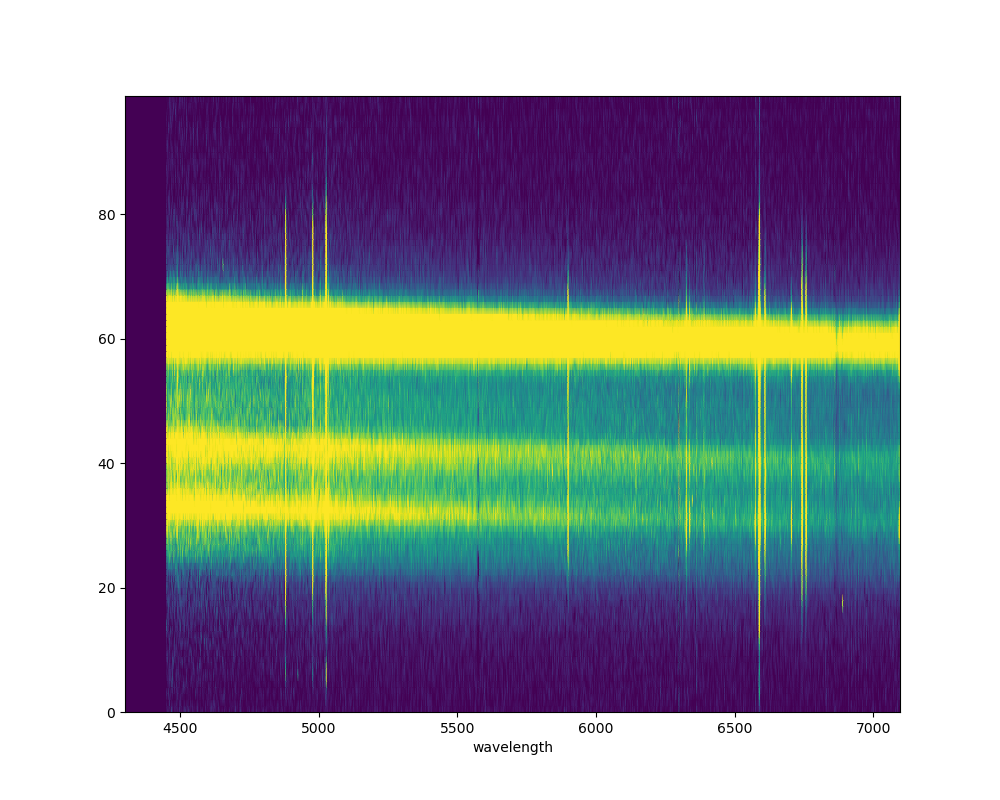

In [133]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [134]:
z = 0.00442
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/PSF/Real_seeing_Mrk1263.txt")
sigmas = seeing / 2.35
n_component = 5
print(sigmas)

[1.00950914 1.1229436  1.00774775 0.9959783  1.11963204 1.01319149]


In [135]:
l_HA

6592.008460000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

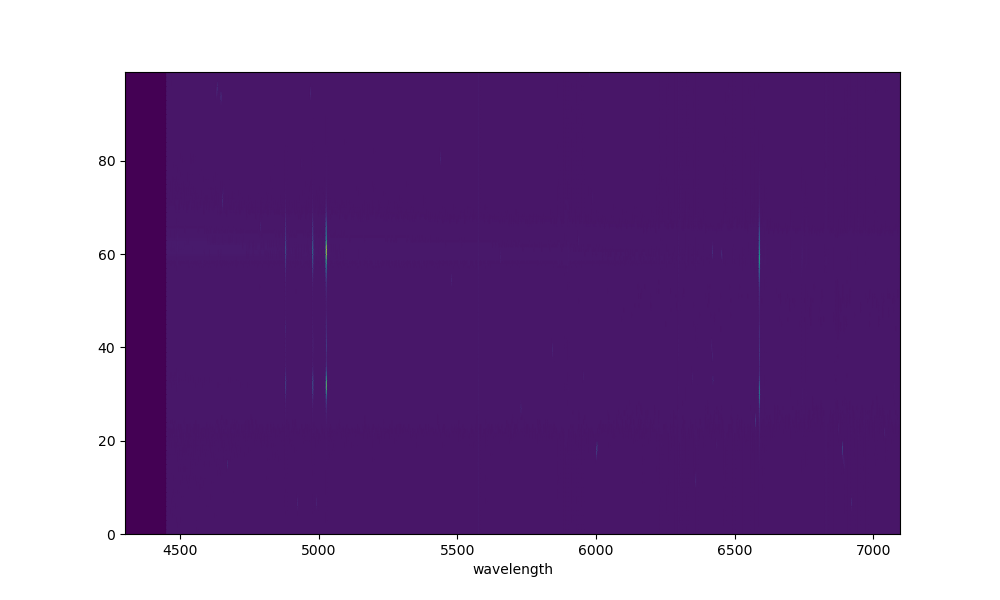

In [136]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[56:156, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

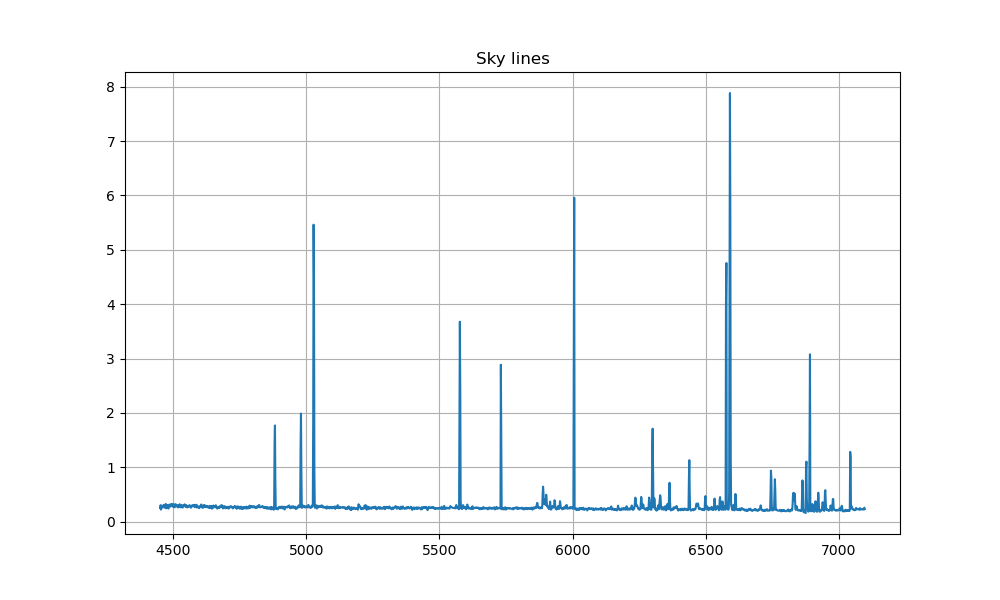

In [137]:
mask_sky = (y > 18)*(y < 28)
mask_wv = wv > 4450.5
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

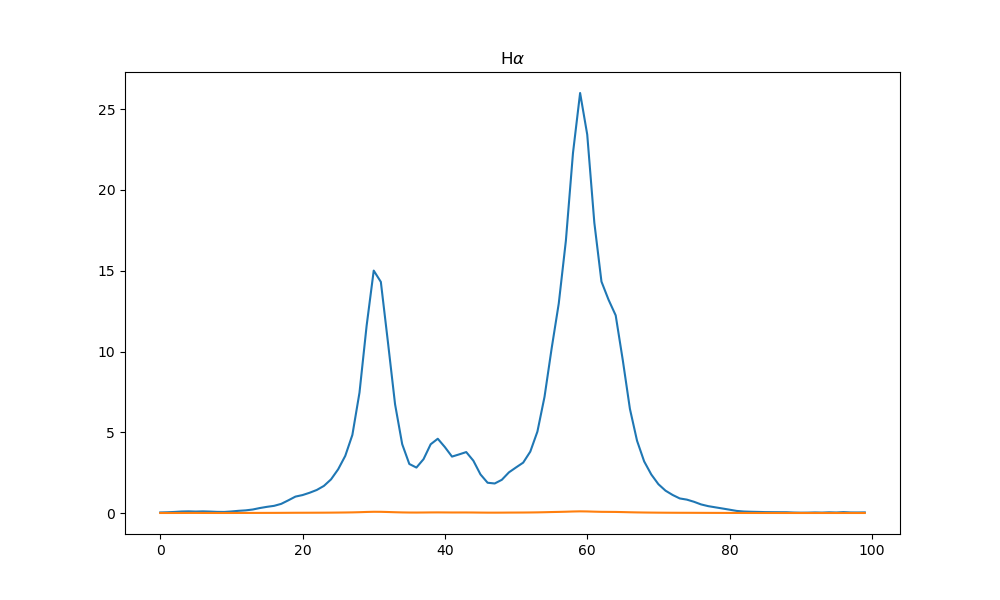

In [138]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [139]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 45)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 45)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 40),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (40, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [140]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2110.612758004275
differential_evolution step 2: f(x)= 1807.3348743786164
differential_evolution step 3: f(x)= 832.9987853723127
differential_evolution step 4: f(x)= 832.9987853723127
differential_evolution step 5: f(x)= 832.9987853723127
differential_evolution step 6: f(x)= 832.9987853723127
differential_evolution step 7: f(x)= 515.9671433284778
differential_evolution step 8: f(x)= 515.9671433284778
differential_evolution step 9: f(x)= 515.9671433284778
differential_evolution step 10: f(x)= 515.9671433284778
differential_evolution step 11: f(x)= 441.83880905772526
differential_evolution step 12: f(x)= 441.83880905772526
differential_evolution step 13: f(x)= 268.45296037525696
differential_evolution step 14: f(x)= 268.45296037525696
differential_evolution step 15: f(x)= 268.45296037525696
differential_evolution step 16: f(x)= 259.4921864457798
differential_evolution step 17: f(x)= 259.4921864457798
differential_evolution step 18: f(x)= 259.492186445

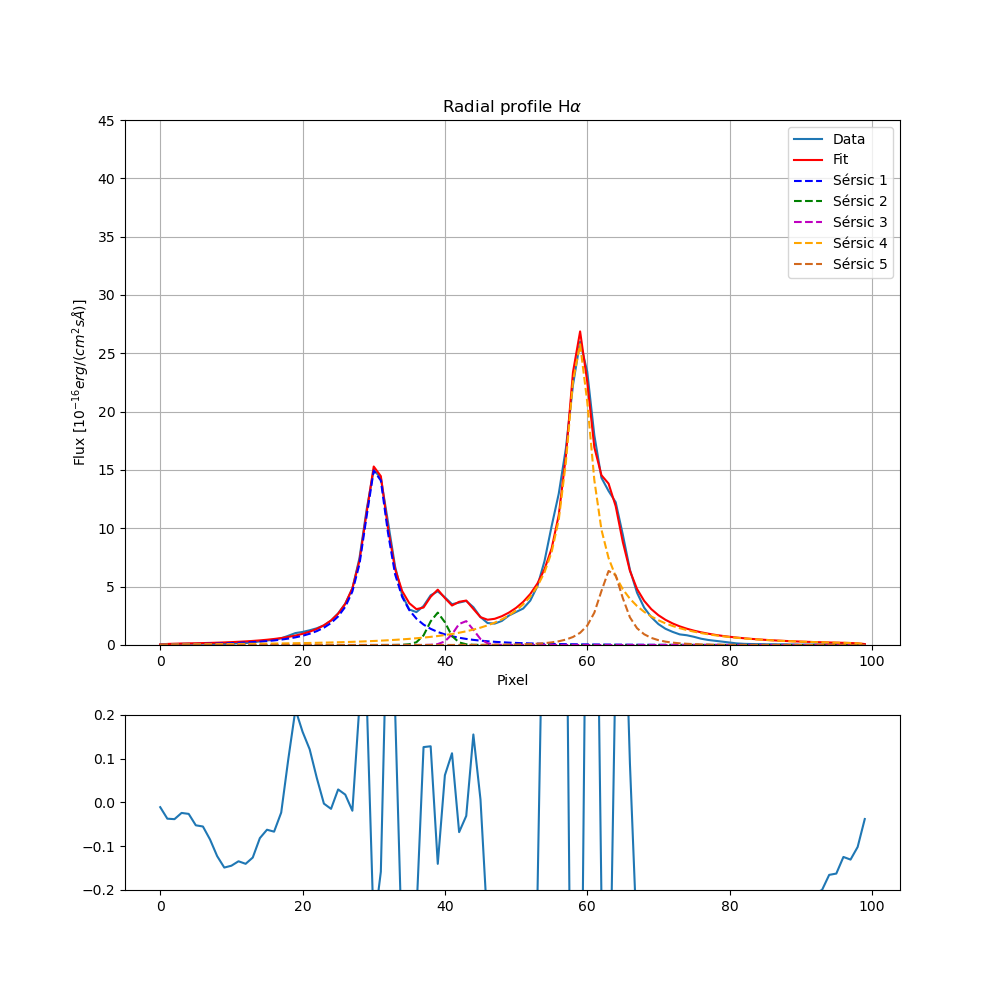

In [141]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [142]:
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1384, r_e=8.9247, n=1.8611, x_0=30.3263
Sérsic 2: I_e=1.8076, r_e=1.4460, n=0.0535, x_0=38.8650
Sérsic 3: I_e=0.7310, r_e=2.7175, n=1.0778, x_0=42.8273
Sérsic 4: I_e=4.3577, r_e=6.4923, n=1.1982, x_0=59.0020
Sérsic 5: I_e=0.1657, r_e=9.8948, n=2.7684, x_0=64.1007
[1.14212831e-01 4.74785883e-01 1.45304102e-01 1.16648919e-02
 1.44975940e+02 1.12499522e+01 3.17805351e+00 1.72251548e-01
 5.39281773e-01 1.19241449e+00 5.71236593e-01 2.35391315e-01
 3.11997969e-01 3.47274414e-01 5.40330586e-02 5.07755650e-02
 1.28203033e-01 5.05691545e+00 6.92683680e-01 1.10085214e-01]
23.390562611305107


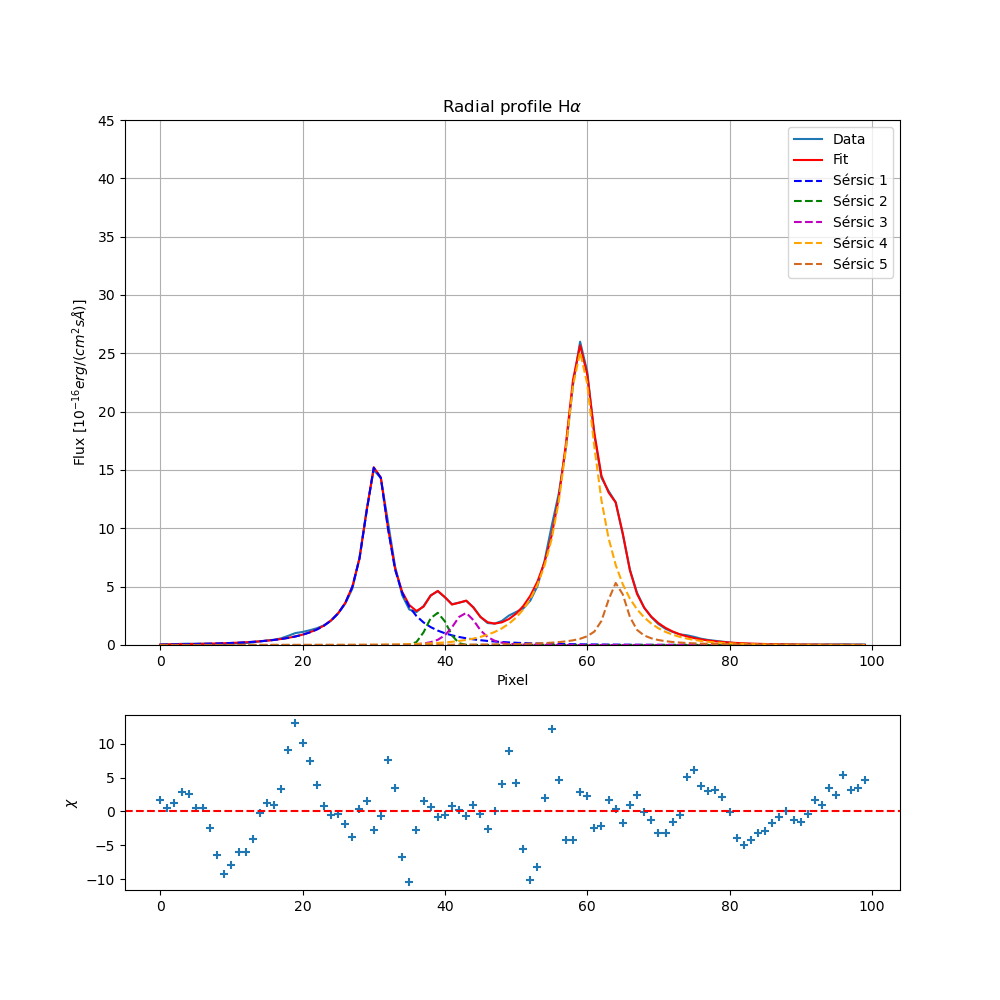

In [143]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [144]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.2, x_0_HA[3]+1.2),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.2, x_0_HA[4]+1.2)
]

In [145]:
bounds

[(0, 1),
 (0, 50),
 (0.1, 10),
 (29.1263, 31.5263),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (37.665, 40.065000000000005),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (41.6273, 44.027300000000004),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (57.802, 60.202000000000005),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (62.9007, 65.3007)]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

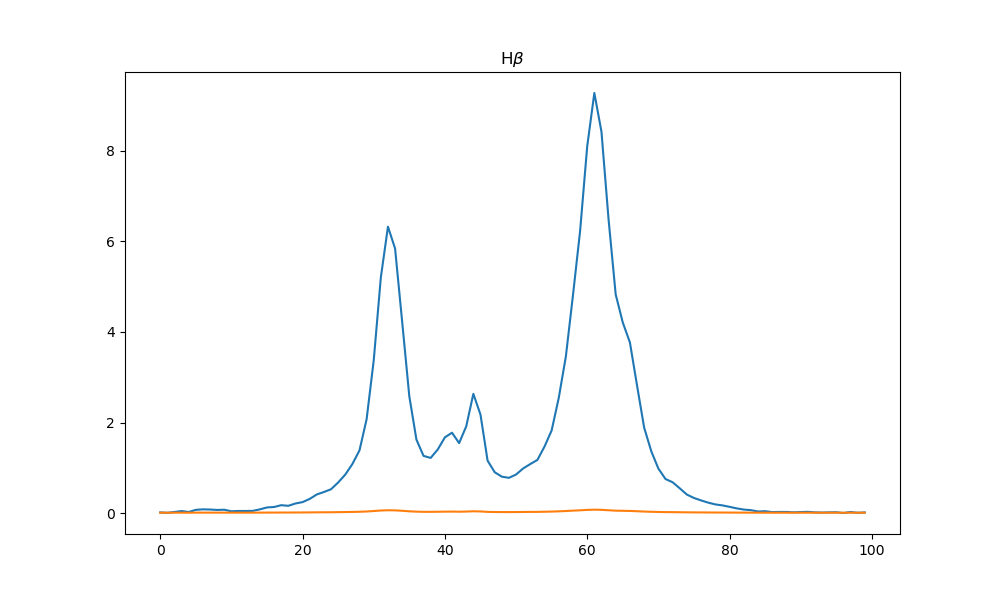

In [146]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [147]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 256.92302464205443
differential_evolution step 2: f(x)= 219.9406715683878
differential_evolution step 3: f(x)= 219.9406715683878
differential_evolution step 4: f(x)= 113.58748934995128
differential_evolution step 5: f(x)= 113.58748934995128
differential_evolution step 6: f(x)= 113.58748934995128
differential_evolution step 7: f(x)= 113.58748934995128
differential_evolution step 8: f(x)= 112.43222935765107
differential_evolution step 9: f(x)= 112.43222935765107
differential_evolution step 10: f(x)= 112.43222935765107
differential_evolution step 11: f(x)= 92.20504369644709
differential_evolution step 12: f(x)= 92.20504369644709
differential_evolution step 13: f(x)= 56.65334122333011
differential_evolution step 14: f(x)= 56.65334122333011
differential_evolution step 15: f(x)= 56.65334122333011
differential_evolution step 16: f(x)= 56.65334122333011
differential_evolution step 17: f(x)= 56.65334122333011
differential_evolution step 18: f(x)= 56.65334122

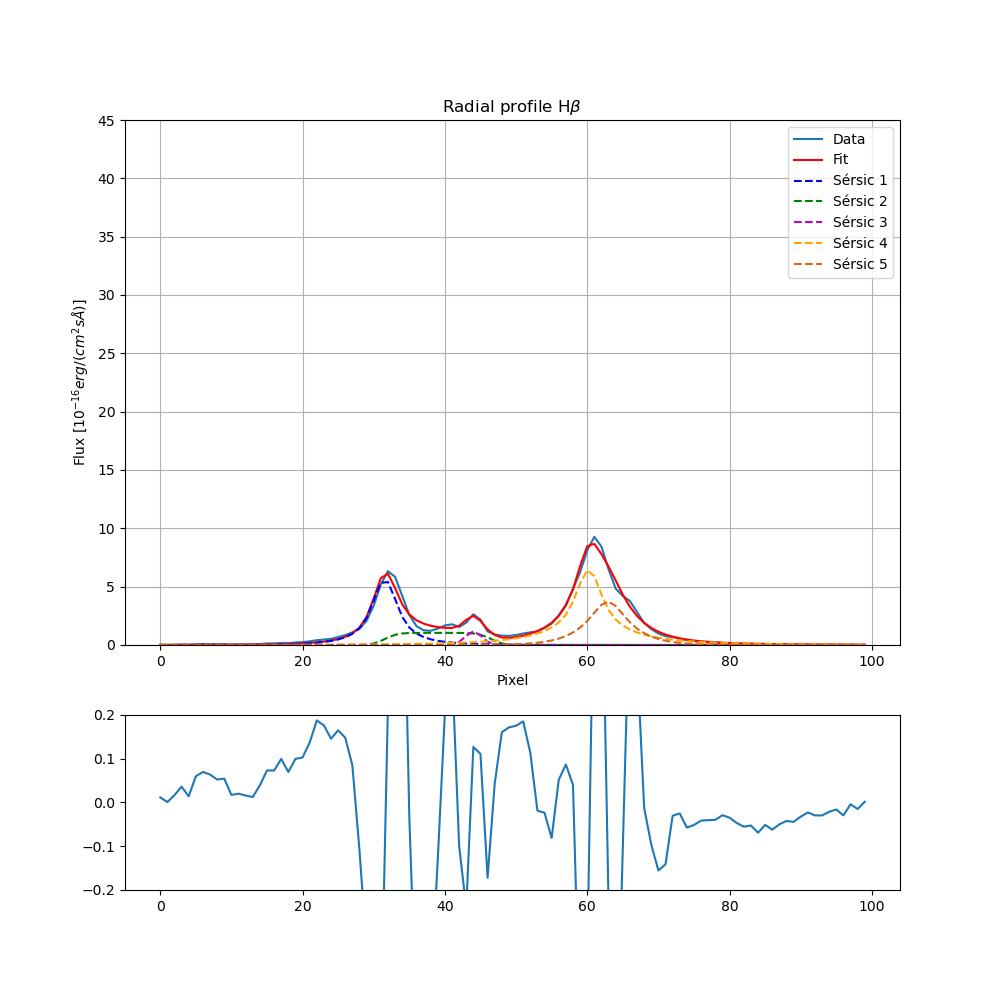

In [148]:
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [149]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2586, r_e=10.2748, n=2.3650, x_0=31.5263
Sérsic 2: I_e=0.5680, r_e=5.8383, n=0.1000, x_0=38.3264
Sérsic 3: I_e=0.0161, r_e=27.6412, n=3.5214, x_0=44.0273
Sérsic 4: I_e=0.5731, r_e=8.6450, n=1.6838, x_0=60.2020
Sérsic 5: I_e=1.0000, r_e=5.3489, n=0.9254, x_0=62.9007
[2.78370874e-01 7.73409524e+00 1.73093987e+00 2.61734013e-01
 1.48958026e+00 2.75973048e+01 1.01221884e+00 1.25963632e+01
 1.22902520e-01 1.75614181e+02 5.56469345e+00 6.94077822e-01
 6.28407700e-01 4.99661499e+00 5.73017549e-01 3.61357224e-01
 7.26210453e-01 1.29482528e+00 2.57799378e-01 1.18976999e+00]
33.775997698551215


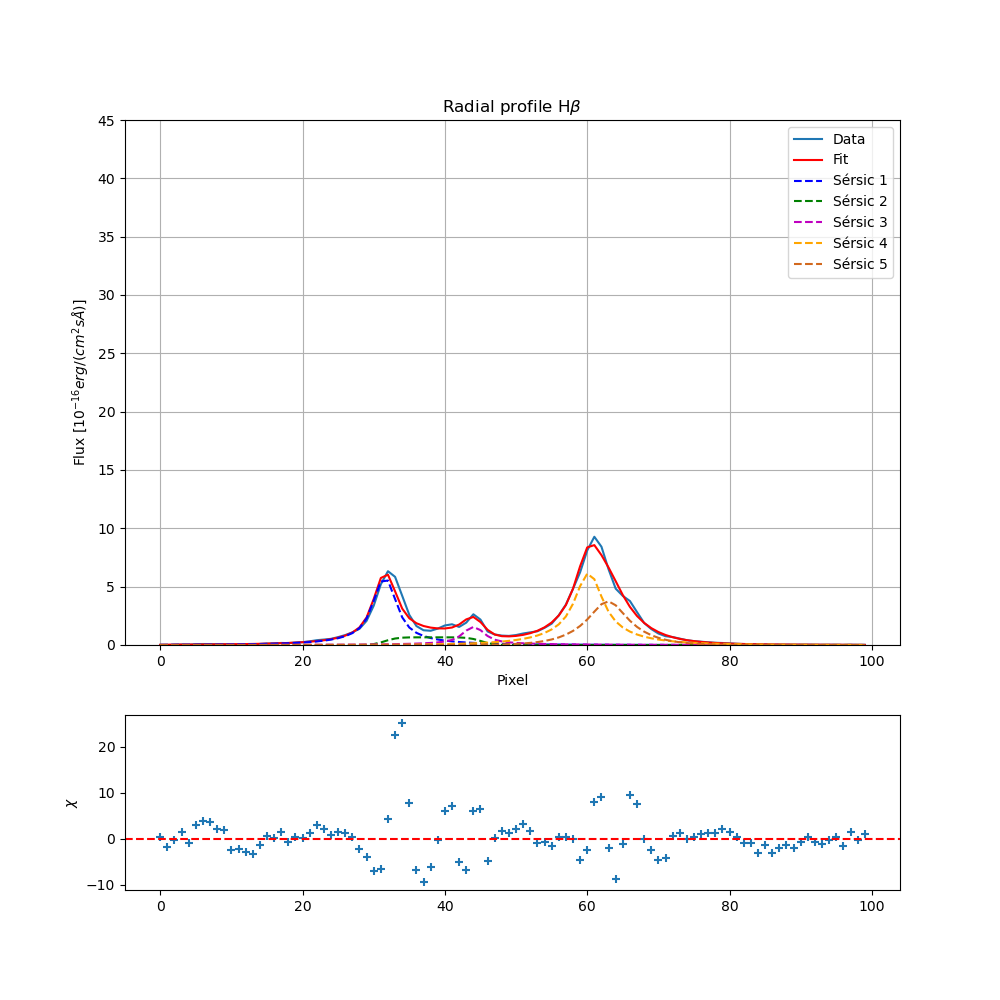

In [150]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

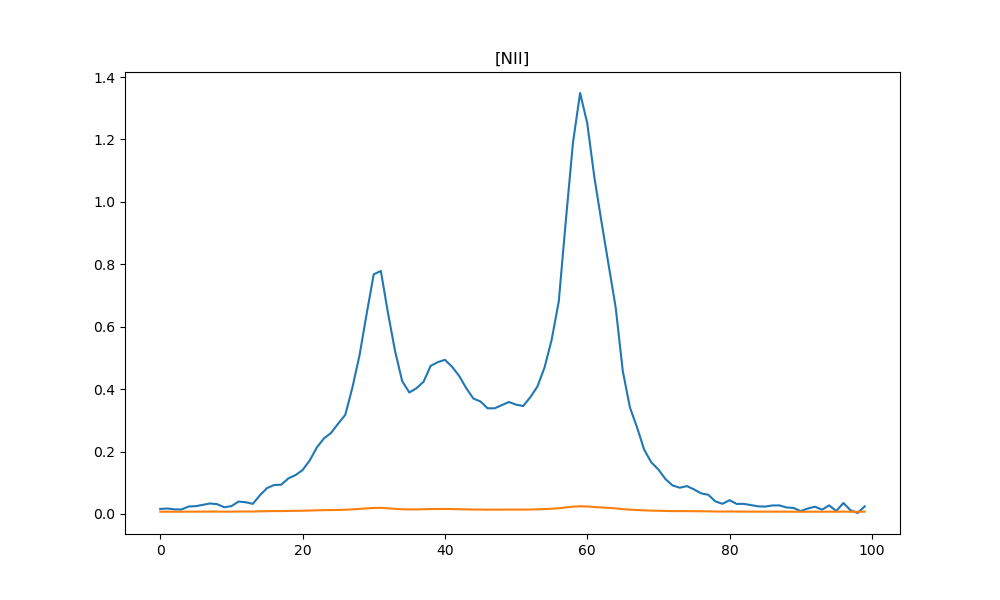

In [151]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [152]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 549.29280054088
differential_evolution step 2: f(x)= 549.29280054088
differential_evolution step 3: f(x)= 549.29280054088
differential_evolution step 4: f(x)= 264.9174816560282
differential_evolution step 5: f(x)= 120.24642227845466
differential_evolution step 6: f(x)= 120.24642227845466
differential_evolution step 7: f(x)= 42.63426521266757
differential_evolution step 8: f(x)= 42.63426521266757
differential_evolution step 9: f(x)= 11.555943965596983
differential_evolution step 10: f(x)= 6.750924378465223
differential_evolution step 11: f(x)= 6.750924378465223
differential_evolution step 12: f(x)= 6.750924378465223
differential_evolution step 13: f(x)= 5.75743751488415
differential_evolution step 14: f(x)= 5.75743751488415
differential_evolution step 15: f(x)= 4.16916981433121
differential_evolution step 16: f(x)= 4.16916981433121
differential_evolution step 17: f(x)= 3.6178430657914094
differential_evolution step 18: f(x)= 1.4110296839757437
differ

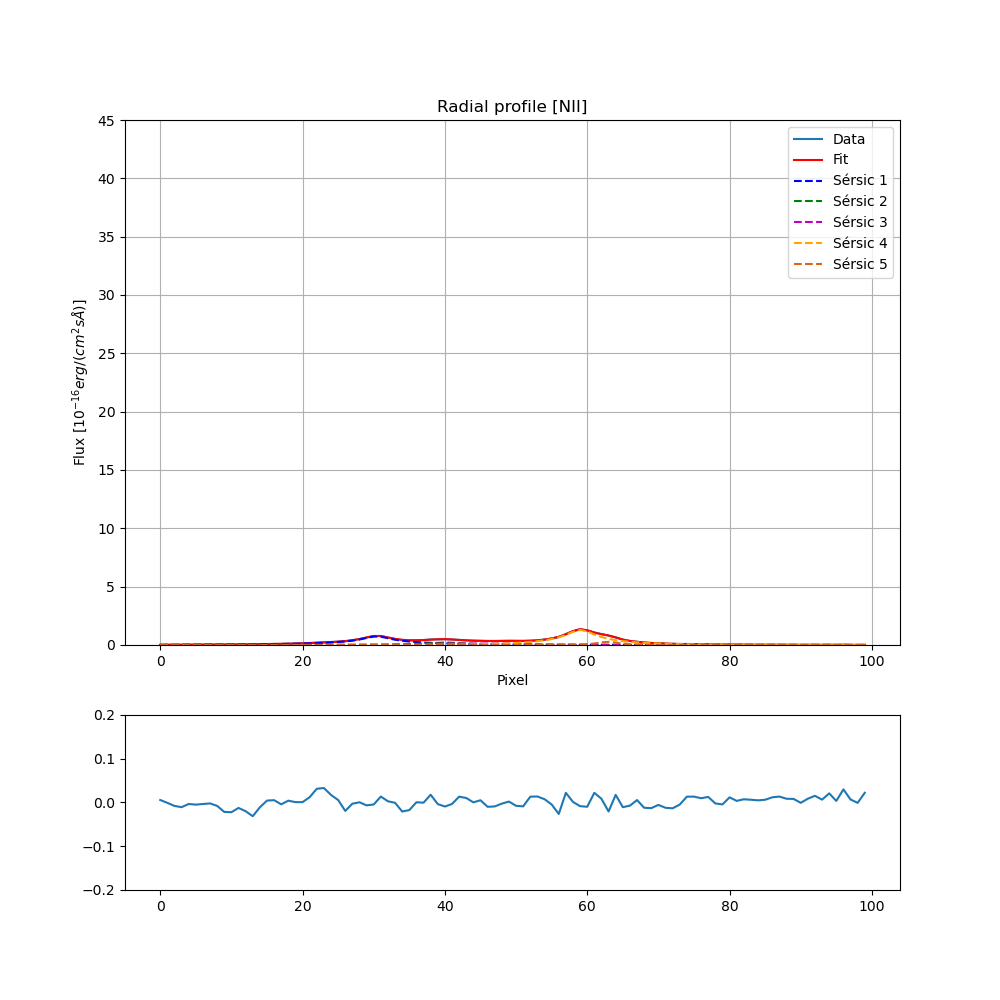

In [153]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [154]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0861, r_e=11.5766, n=1.3625, x_0=30.3653
Sérsic 2: I_e=0.0067, r_e=49.9990, n=2.2057, x_0=40.0650
Sérsic 3: I_e=0.1116, r_e=5.8664, n=0.1151, x_0=43.8842
Sérsic 4: I_e=0.1412, r_e=10.2214, n=1.4761, x_0=58.9930
Sérsic 5: I_e=0.1311, r_e=1.8470, n=0.6902, x_0=62.9007
[1.30717623e-02 1.64393319e+00 1.03802323e-01 9.48110695e-02
 1.09446488e-02 4.94077446e+01 1.00189167e+00 3.54294640e-01
 3.75252478e-02 1.71402324e+00 9.85006216e-02 4.30659710e-01
 2.46051948e-02 1.19760620e+00 1.13786517e-01 1.14937460e-01
 6.50262524e-02 5.65956593e-01 3.89109098e-01 2.55724936e-01]
1.6271269176456127


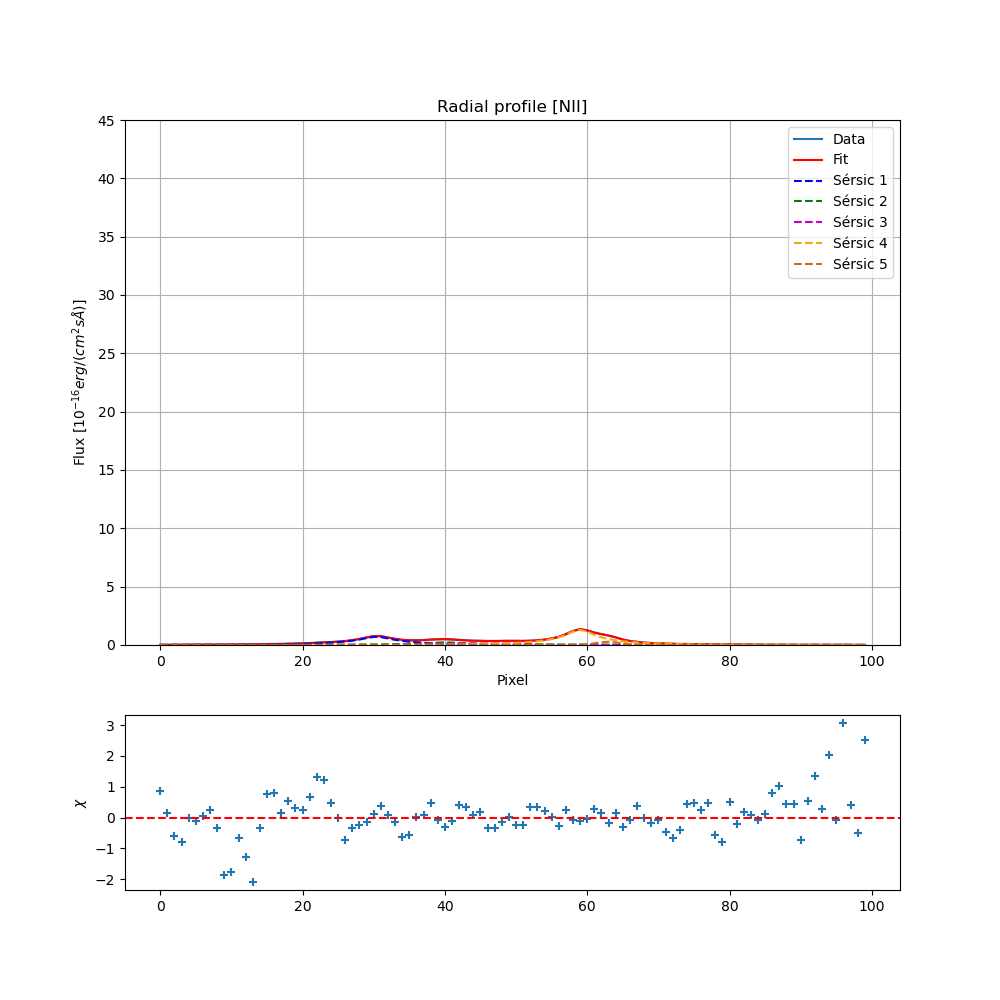

In [155]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

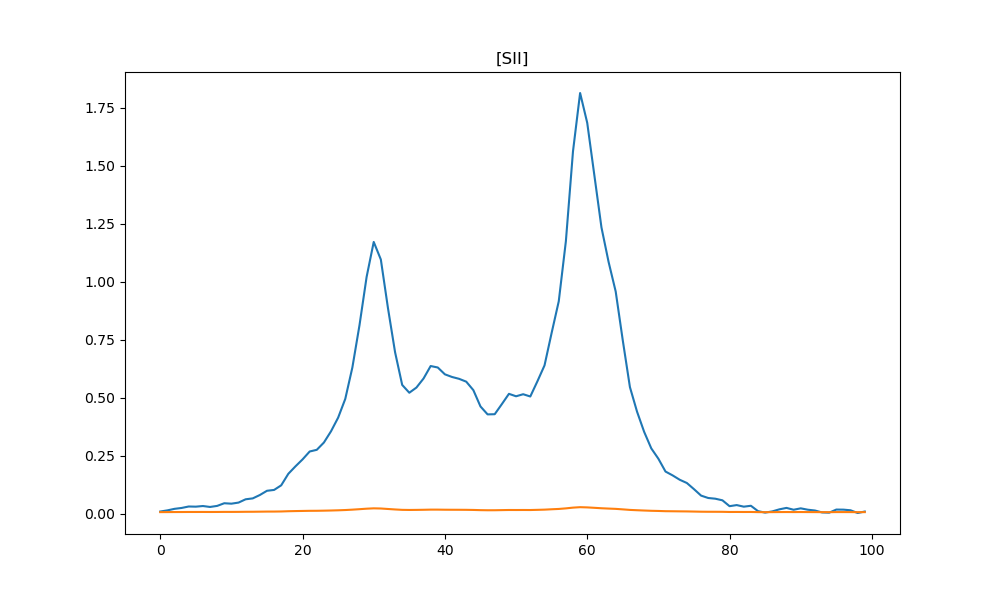

In [156]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [157]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 511.1177770635065
differential_evolution step 2: f(x)= 15.725245506442258
differential_evolution step 3: f(x)= 15.232095914492708
differential_evolution step 4: f(x)= 15.232095914492708
differential_evolution step 5: f(x)= 15.232095914492708
differential_evolution step 6: f(x)= 15.232095914492708
differential_evolution step 7: f(x)= 15.232095914492708
differential_evolution step 8: f(x)= 15.232095914492708
differential_evolution step 9: f(x)= 15.232095914492708
differential_evolution step 10: f(x)= 15.232095914492708
differential_evolution step 11: f(x)= 15.232095914492708
differential_evolution step 12: f(x)= 13.268216585621468
differential_evolution step 13: f(x)= 13.268216585621468
differential_evolution step 14: f(x)= 7.229281390285855
differential_evolution step 15: f(x)= 7.229281390285855
differential_evolution step 16: f(x)= 7.229281390285855
differential_evolution step 17: f(x)= 7.229281390285855
differential_evolution step 18: f(x)= 7.22928

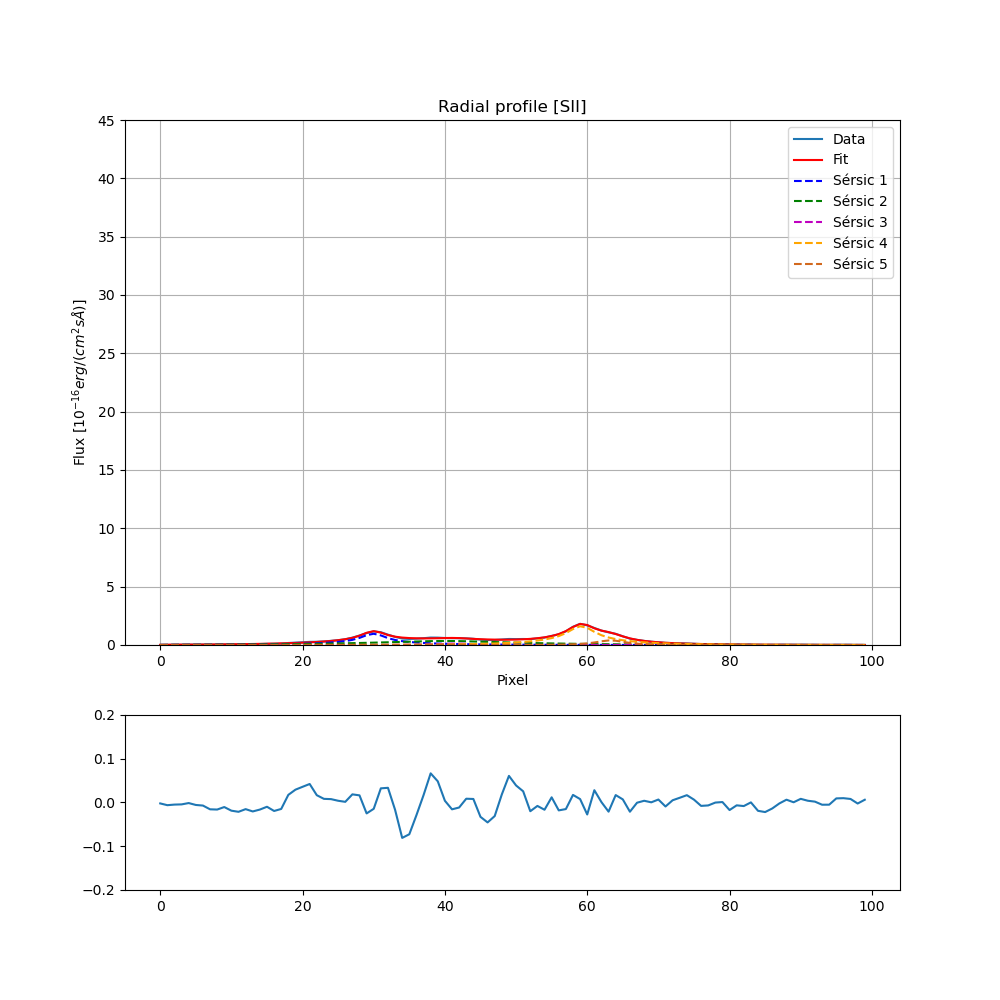

In [158]:
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [160]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0209, r_e=26.5243, n=2.5666, x_0=30.0174
Sérsic 2: I_e=0.2098, r_e=12.8826, n=0.3925, x_0=37.7765
Sérsic 3: I_e=0.1052, r_e=3.0860, n=0.1000, x_0=41.6273
Sérsic 4: I_e=0.1786, r_e=9.4455, n=1.4648, x_0=59.1789
Sérsic 5: I_e=0.0536, r_e=8.4048, n=1.4531, x_0=63.3154
[1.35636327e-02 1.13230221e+01 4.66378750e-01 7.66959672e-02
 3.04942850e-02 1.11601958e+00 5.21923352e-02 1.90322372e+00
 1.25387383e-01 3.95706501e+00 3.81877846e-01 3.65984295e-01
 8.74385794e-02 6.06107900e+00 3.27259391e-01 1.05015862e-01
 7.10872967e-02 1.41890874e+01 9.17726082e-01 3.23950509e-01]
2.5356140167722137


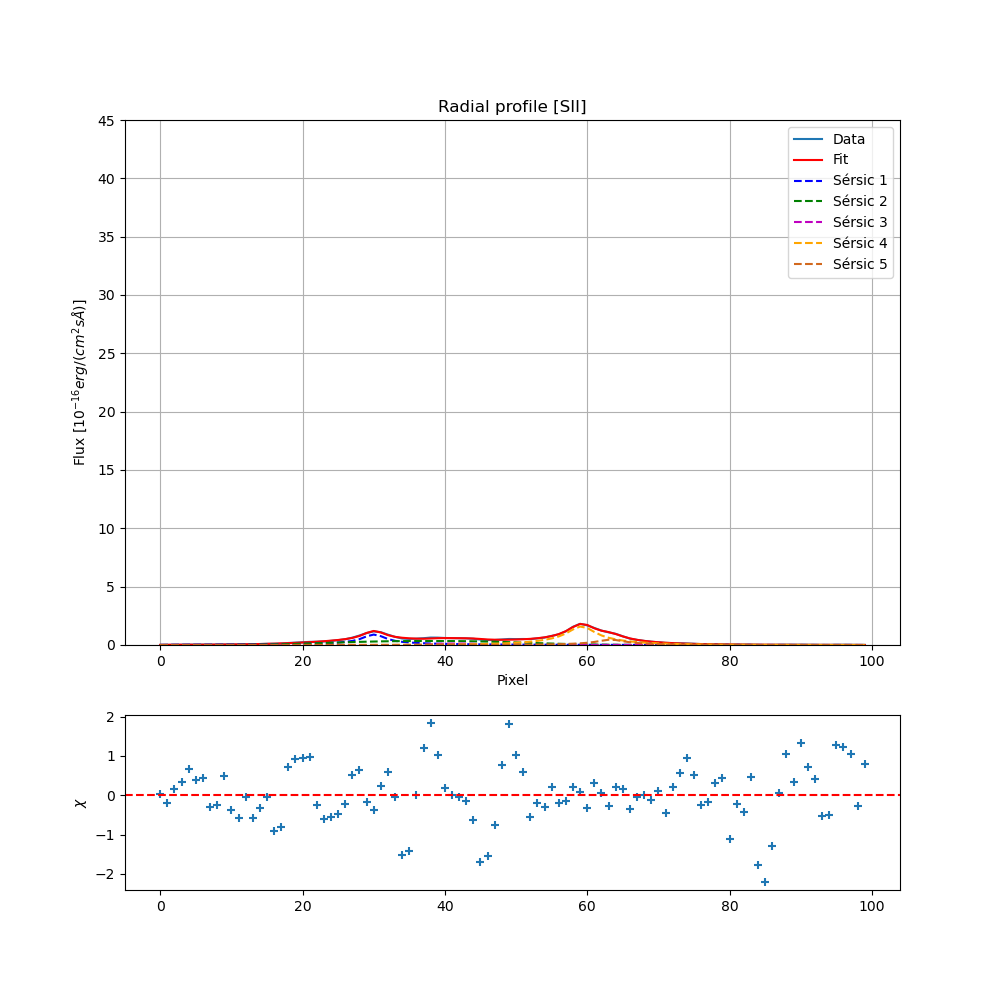

In [161]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

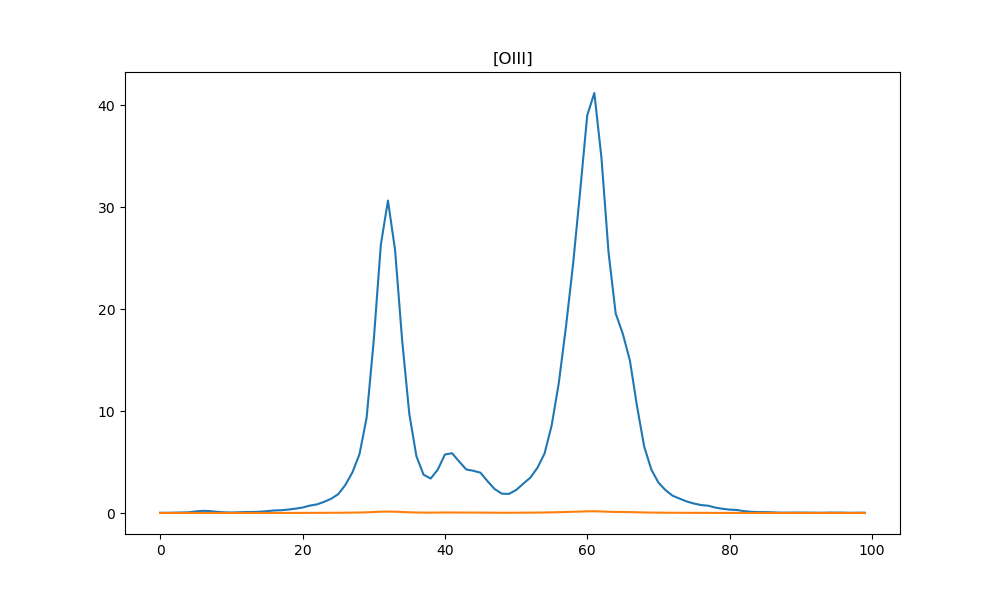

In [162]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [163]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4235.8103233039865
differential_evolution step 2: f(x)= 2185.2425926480305
differential_evolution step 3: f(x)= 2185.2425926480305
differential_evolution step 4: f(x)= 1582.8893923296384
differential_evolution step 5: f(x)= 1582.8893923296384
differential_evolution step 6: f(x)= 1582.8893923296384
differential_evolution step 7: f(x)= 1582.8893923296384
differential_evolution step 8: f(x)= 1582.8893923296384
differential_evolution step 9: f(x)= 1309.780925070027
differential_evolution step 10: f(x)= 1021.0233491905134
differential_evolution step 11: f(x)= 997.1237770791098
differential_evolution step 12: f(x)= 862.396768502889
differential_evolution step 13: f(x)= 862.396768502889
differential_evolution step 14: f(x)= 862.396768502889
differential_evolution step 15: f(x)= 772.4308039512299
differential_evolution step 16: f(x)= 722.3485233980036
differential_evolution step 17: f(x)= 722.3485233980036
differential_evolution step 18: f(x)= 722.348523398

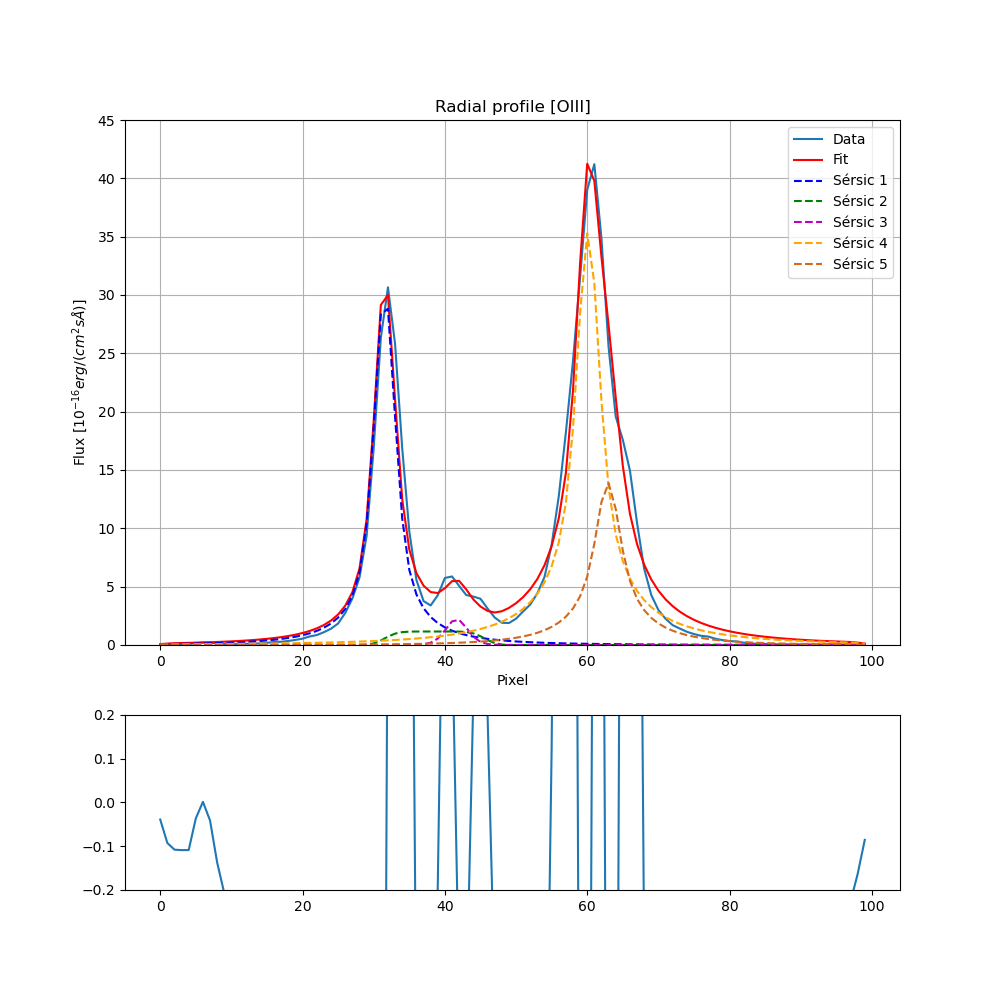

In [164]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [165]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = radial_profile_error_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: overflow encountered in multiply
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=2.7801, r_e=5.6298, n=1.9324, x_0=31.9707
Sérsic 2: I_e=0.0000, r_e=15.2219, n=0.0155, x_0=41.4487
Sérsic 3: I_e=0.4659, r_e=3.7554, n=0.0301, x_0=42.4350
Sérsic 4: I_e=4.7823, r_e=6.9505, n=1.3769, x_0=60.6279
Sérsic 5: I_e=3.1981, r_e=5.8010, n=0.0478, x_0=61.7813
[2.51373469e-01 2.64091801e-01 8.63103267e-02 2.95669366e-02
 7.91154930e-02 3.91602882e+02 2.22856121e+00 3.85272359e+02
 2.31612075e+01 1.16516782e+00 3.52830640e-01 1.03358041e-01
 4.44590167e-01 2.27317184e-01 5.80501291e-02 5.51348710e-02
 1.77702732e+01 6.57007138e+00 1.54669997e-01 5.06471064e+00]
28.22665718140741


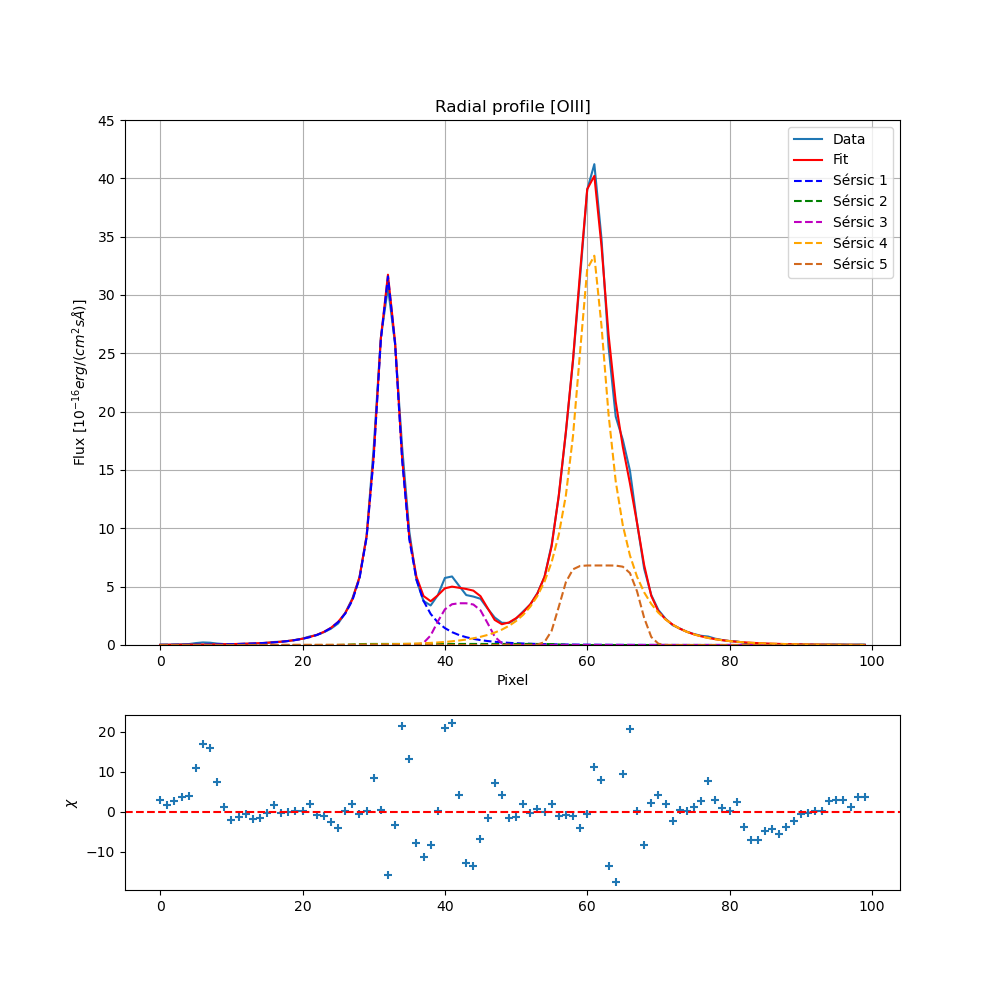

In [166]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [167]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

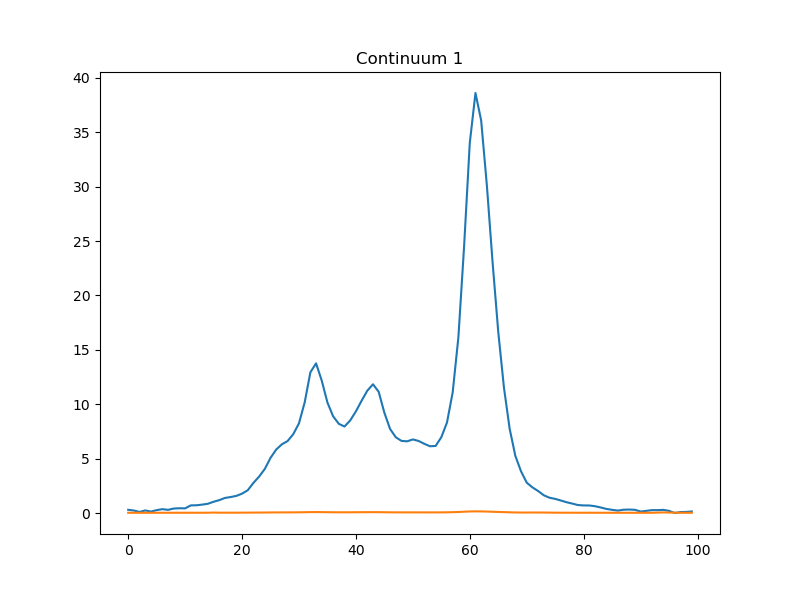

In [168]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [169]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1426.817926499993
differential_evolution step 2: f(x)= 1426.817926499993
differential_evolution step 3: f(x)= 1020.399734316549
differential_evolution step 4: f(x)= 1020.399734316549
differential_evolution step 5: f(x)= 779.5579221343369
differential_evolution step 6: f(x)= 779.5579221343369
differential_evolution step 7: f(x)= 779.5579221343369
differential_evolution step 8: f(x)= 398.5560533800766
differential_evolution step 9: f(x)= 281.81486360782475
differential_evolution step 10: f(x)= 281.81486360782475
differential_evolution step 11: f(x)= 281.81486360782475
differential_evolution step 12: f(x)= 281.81486360782475
differential_evolution step 13: f(x)= 281.81486360782475
differential_evolution step 14: f(x)= 281.81486360782475
differential_evolution step 15: f(x)= 281.81486360782475
differential_evolution step 16: f(x)= 281.81486360782475
differential_evolution step 17: f(x)= 281.81486360782475
differential_evolution step 18: f(x)= 281.814863

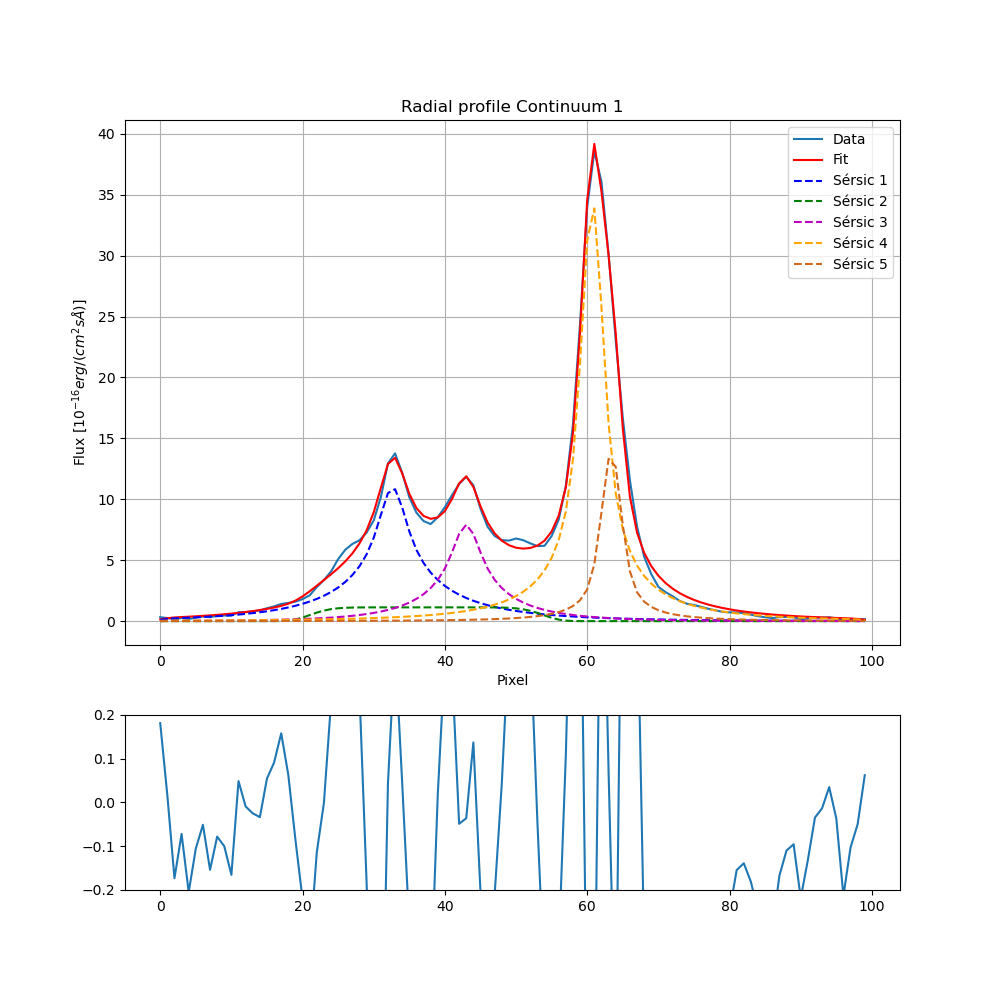

In [170]:
def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [171]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9469, r_e=15.8864, n=1.5496, x_0=32.5945
Sérsic 2: I_e=1.0000, r_e=14.1877, n=0.1000, x_0=38.5280
Sérsic 3: I_e=0.8263, r_e=13.6940, n=1.4828, x_0=43.0206
Sérsic 4: I_e=1.0000, r_e=13.8123, n=2.6457, x_0=60.5877
Sérsic 5: I_e=1.0000, r_e=6.7021, n=2.2422, x_0=63.3403
[ 0.37878995  6.5694359   0.26225711  0.13877775  0.96810131  6.26540847
  0.1218939   1.49840525  0.76698859 15.83919528  0.61782413  0.15538985
  0.70610548  7.78935689  0.48647709  0.11925006  1.38558698  6.71565406
  1.04294989  0.20622313]
19.045293761320835


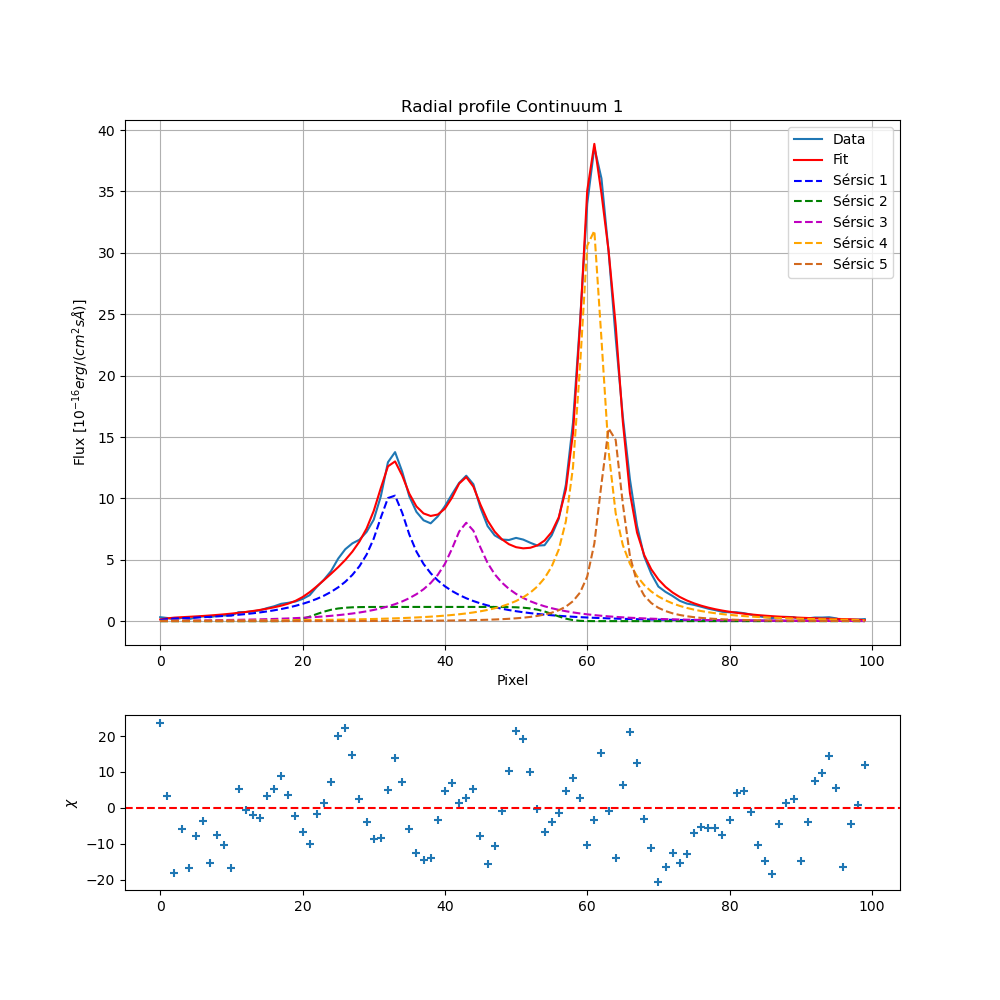

In [172]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

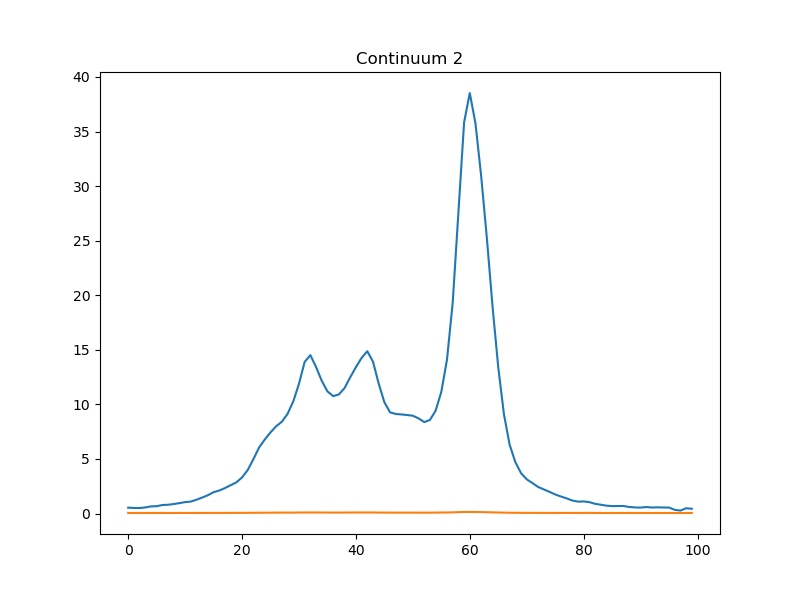

In [173]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [174]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1545.3393537208392
differential_evolution step 2: f(x)= 1430.1308775818018
differential_evolution step 3: f(x)= 1430.1308775818018
differential_evolution step 4: f(x)= 1068.3872557205998
differential_evolution step 5: f(x)= 712.160922086473
differential_evolution step 6: f(x)= 712.160922086473
differential_evolution step 7: f(x)= 712.160922086473
differential_evolution step 8: f(x)= 625.6341614925954
differential_evolution step 9: f(x)= 521.8939439646952
differential_evolution step 10: f(x)= 521.8939439646952
differential_evolution step 11: f(x)= 521.8939439646952
differential_evolution step 12: f(x)= 521.8939439646952
differential_evolution step 13: f(x)= 521.8939439646952
differential_evolution step 14: f(x)= 501.93290827378644
differential_evolution step 15: f(x)= 404.99178341233505
differential_evolution step 16: f(x)= 404.99178341233505
differential_evolution step 17: f(x)= 404.99178341233505
differential_evolution step 18: f(x)= 404.9917834123

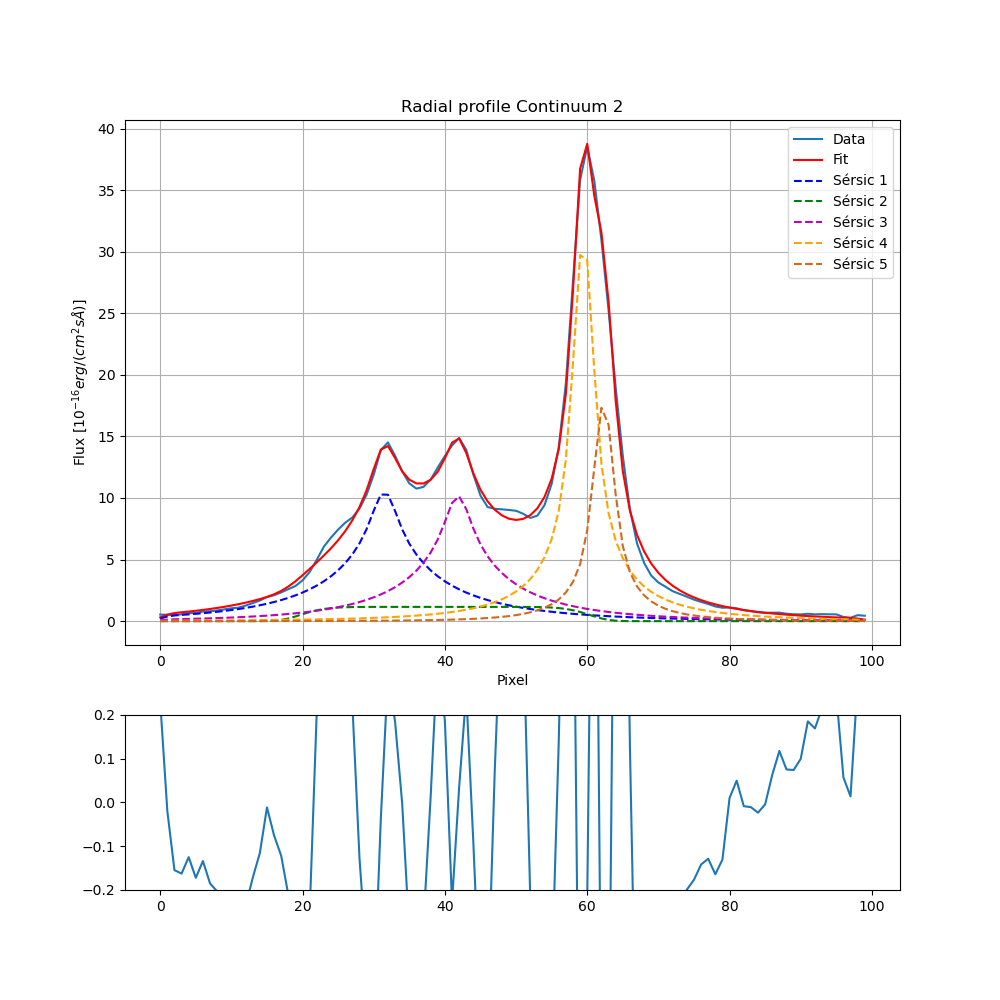

In [176]:
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [177]:
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[5], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2)#, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2, radial_profile_error_continuum_2,
                                                                          sigmas[5], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.9020, r_e=20.1357, n=1.4789, x_0=31.6137
Sérsic 2: I_e=0.3288, r_e=21.6449, n=0.0310, x_0=42.1039
Sérsic 3: I_e=0.7348, r_e=17.8362, n=1.6081, x_0=41.7721
Sérsic 4: I_e=0.4781, r_e=29.8626, n=2.5685, x_0=59.2940
Sérsic 5: I_e=9.6088, r_e=2.9027, n=0.5368, x_0=61.5232
[ 0.1758447   5.90798383  0.13847598  0.09975447  1.11219676  1.21158063
  0.02553758  0.86243945  0.52874656 16.79942189  0.4692462   0.08776211
  0.14733627  7.05344609  0.23156514  0.11289234  1.09634551  0.16954836
  0.05820192  0.15450247]
9.89590813087725


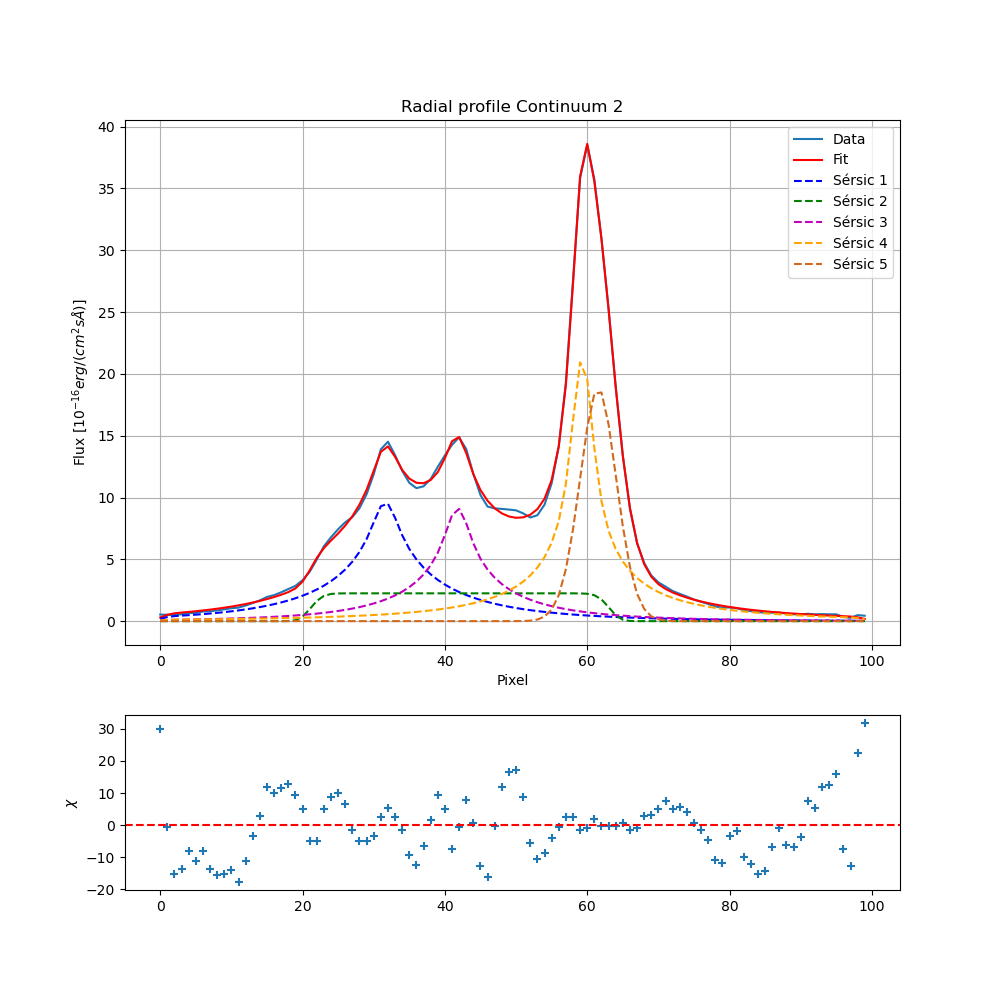

In [178]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

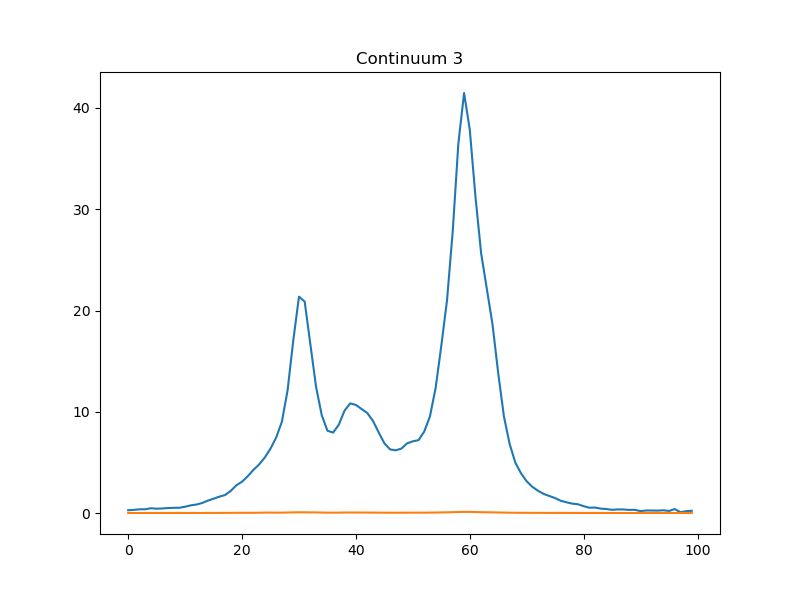

In [179]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [180]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4134.603961090466
differential_evolution step 2: f(x)= 2021.2063239057854
differential_evolution step 3: f(x)= 1125.1001502943582
differential_evolution step 4: f(x)= 1125.1001502943582
differential_evolution step 5: f(x)= 800.1053075838389
differential_evolution step 6: f(x)= 800.1053075838389
differential_evolution step 7: f(x)= 800.1053075838389
differential_evolution step 8: f(x)= 800.1053075838389
differential_evolution step 9: f(x)= 800.1053075838389
differential_evolution step 10: f(x)= 800.1053075838389
differential_evolution step 11: f(x)= 622.6566682136902
differential_evolution step 12: f(x)= 463.38346289499447
differential_evolution step 13: f(x)= 463.38346289499447
differential_evolution step 14: f(x)= 463.38346289499447
differential_evolution step 15: f(x)= 463.38346289499447
differential_evolution step 16: f(x)= 463.38346289499447
differential_evolution step 17: f(x)= 463.38346289499447
differential_evolution step 18: f(x)= 455.671858

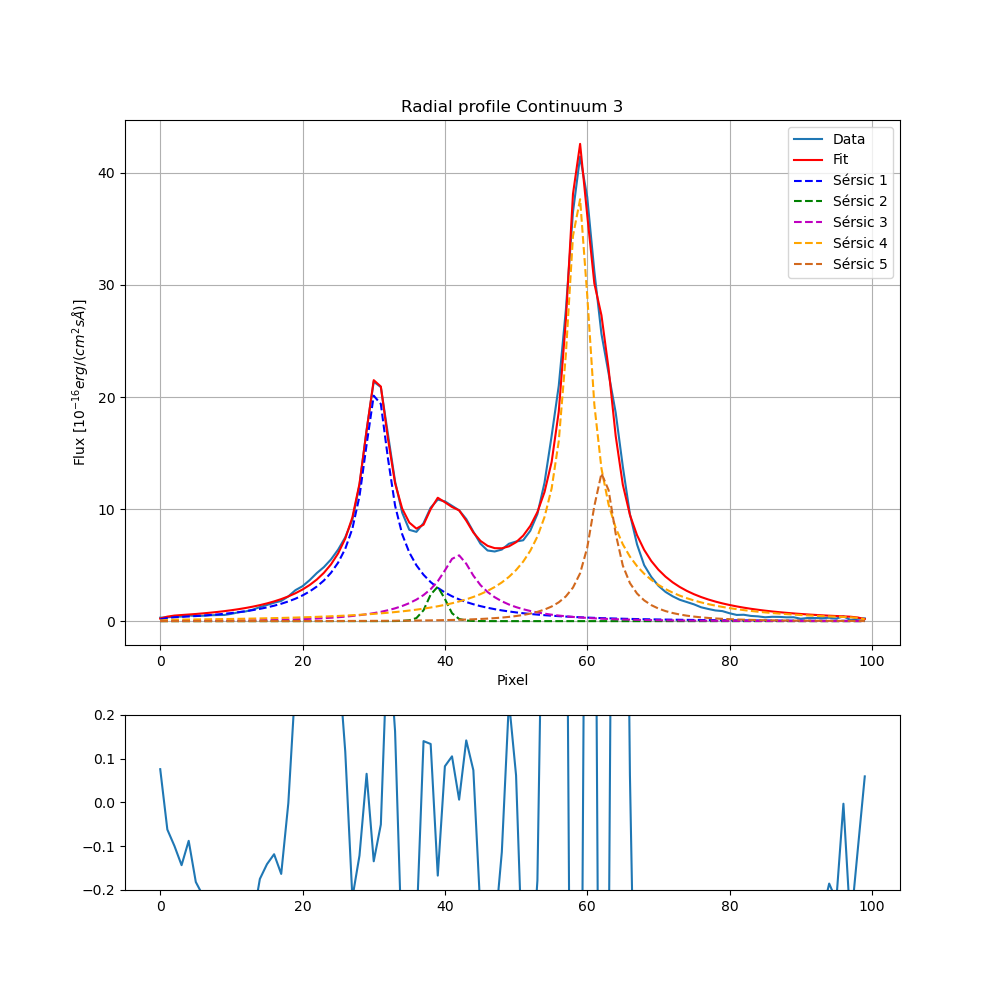

In [181]:
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [182]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          radial_profile_error_continuum_3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16972\1200208441.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.5273, r_e=14.7225, n=1.7379, x_0=30.4501
Sérsic 2: I_e=5.3175, r_e=2.6579, n=0.2410, x_0=40.5518
Sérsic 3: I_e=1.6266, r_e=3.4979, n=0.3972, x_0=48.1453
Sérsic 4: I_e=2.5227, r_e=11.6401, n=1.6312, x_0=59.0848
Sérsic 5: I_e=8.8913, r_e=3.8380, n=0.2796, x_0=60.3068
[0.1418615  0.89278084 0.08798016 0.02038977 0.42769532 0.17837783
 0.0584527  0.26033165 0.59665033 0.94766374 0.22694529 0.79467224
 0.35075297 0.79252769 0.0804882  0.06263117 0.48175224 0.10269913
 0.04252768 0.11894648]
14.487547576526643


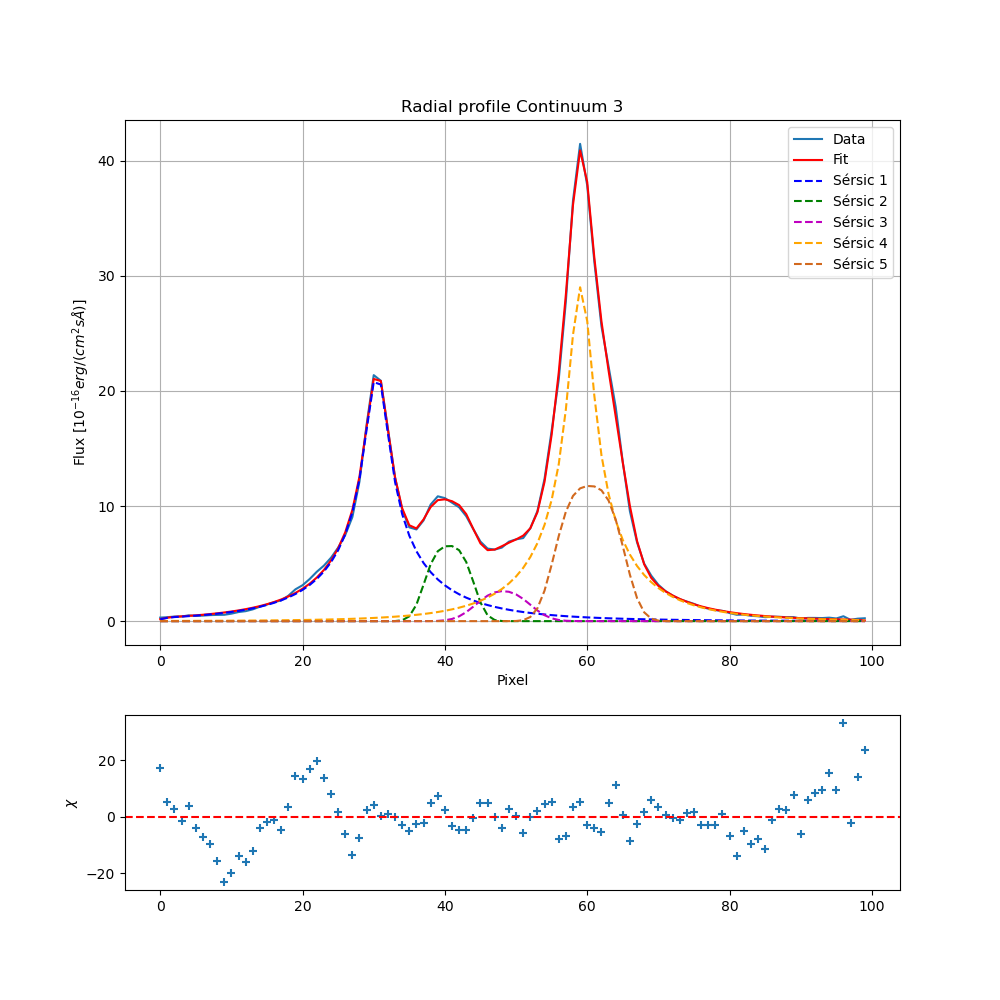

In [183]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [184]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [ ]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
